In [87]:
import requests
from requests.packages.urllib3.exceptions import InsecureRequestWarning
requests.packages.urllib3.disable_warnings(InsecureRequestWarning)
import time
import math
from PIL import Image, ImageFont, ImageDraw, ImageOps, ImageFilter, ImageChops
from io import BytesIO
from datetime import datetime
import random
#import inky
#from inky import InkyPHAT
from IPython.display import display
from IPython.display import clear_output

In [2]:
class Wiim:
    none_metadata = {'album': 'unknow', 'title': 'unknow', 'subtitle': 'unknow', 'artist': 'unknow', 'albumArtURI': 'un_known', 'sampleRate': 'unknow', 'bitDepth': 'unknow', 'bitRate': '0', 'trackId': 'unknow'}
    def __init__(self, ip_port: str):
        self.ip = ip_port
        self.s = requests.session()
        self.s.verify = False
        
    def _cmd(self, cmd: str):
        try:
            cmd = f"https://{self.ip}/httpapi.asp?command={cmd}"
            ret = self.s.get(cmd)
            ret.encoding = 'UTF-8'
            return ret.json()
        except:
            return None
            
    def media_info(self):
        ret =  self._cmd('getMetaInfo')
        ret = ret['metaData']
        return ret

    def get_cover(self) -> str:
        img_url = self.media_info()['albumArtURI']
        if img_url != 'un_known':
            return img_url
        else:
            return None

    def fetch_img(self, img_url):
        try:
            response = self.s.get(img_url)
            img_url = Image.open(BytesIO(response.content))
            return img_url
        except:
            return None

In [71]:
dev = Wiim('192.168.0.42')

In [72]:
med = dev.media_info()
print(med)

{'album': 'unknow', 'title': 'unknow', 'subtitle': 'unknow', 'artist': 'unknow', 'albumArtURI': 'un_known', 'sampleRate': 'unknow', 'bitDepth': 'unknow', 'bitRate': '0', 'trackId': 'unknow'}


476 640 44 160


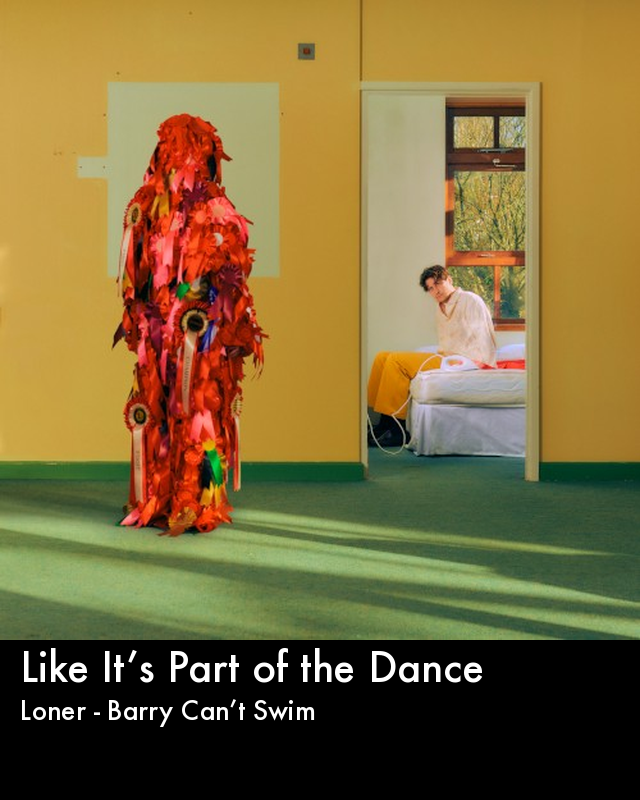

In [ ]:
track_id = '0'
res = (640, 800)
t = ""
font_family = "/System/Library/Fonts//Futura.ttc"
while True:
    media_info = dev.media_info()
    if media_info['trackId'] in ['0', 'unknow']  and t != datetime.now().strftime("%M"):
        clear_output()
        font = ImageFont.truetype(font_family, 200)
        time_s = datetime.now().strftime("%H:%M")
        _, _, tw, th = font.getbbox(time_s)
        extended_y = Image.new('RGBA', res, (255,255,255,0))
        draw = ImageDraw.Draw(extended_y)
        t = time.time()/30/60
        draw.circle((320 + 160*math.sin(-t/5), 320+ 160*math.cos(-t/5)), 400, (127, 127, 0, 255))
        extended_m = Image.new('RGBA', res, (255,255,255,0))
        draw = ImageDraw.Draw(extended_m)
        draw.circle((320 + 160*math.sin(t/7), 320+ 160*math.cos(t/7)), 400, (127, 0, 127, 255))
        extended_c = Image.new('RGBA', res, (255,255,255,0))
        draw = ImageDraw.Draw(extended_c)
        draw.circle((320 + 160*math.sin(t/11), 320+ 160*math.cos(t/11)), 400, (0, 127, 127, 255))
        extended = Image.new('RGBA', res, (255,255,255,255))
        extended = ImageChops.multiply(extended, extended_c.filter(filter=ImageFilter.GaussianBlur(30)))
        extended = ImageChops.multiply(extended, extended_m.filter(filter=ImageFilter.GaussianBlur(30)))
        extended = ImageChops.multiply(extended, extended_y.filter(filter=ImageFilter.GaussianBlur(30)))
        draw = ImageDraw.Draw(extended)
        draw.text((320, 320), time_s, (255, 255, 255, 255), font=font, anchor="ms", outline=None)
        display(extended)
    else:
        if track_id != media_info['trackId']:
            clear_output()
            img = dev.fetch_img(media_info['albumArtURI'])
            img = img.resize((res[0],res[0]), Image.Resampling.LANCZOS)
            meta_data = dev.media_info()
            annotation1, annotation2 = f"{meta_data['title']}", f"{meta_data['album']} - {meta_data['artist']}"
            extended = ImageOps.expand(img, border=(0,0,0,res[1]-res[0]), fill=(0,0,0))
            w, h = extended.size
            font_size_1_found = False
            font_size = 100
            font1 = ImageFont.truetype(font_family, font_size)
            _, _, tw, th = font1.getbbox(annotation1)
            for k in range(1, 999999, 10):
                font_size = k
                font1 = ImageFont.truetype(font_family, font_size)
                _, _, tw, th = font1.getbbox(annotation1)
                if 2*th > h - res[0] or 10*(tw + 40) > 8*w:
                    print(tw, w, th,  h - res[0])
                    font_size = k - 1
                    font1 = ImageFont.truetype(font_family, font_size)
                    break
            line_2_does_not_fit = True
            for _ in range(10):
                if line_2_does_not_fit:
                    for k in range(int(2*font_size/3), 15, -1):
                        font2 = ImageFont.truetype(font_family, k)
                        sizes= [a for a in zip(*[font2.getbbox(line) for line in annotation2.split('\r\n')])] 
                        #print(sizes)
                        th = sum(sizes[3])
                        tw = max(sizes[2])
                        if 2*th < h - res[0] and tw + 40 < w:
                            font_size = k
                            font2 = ImageFont.truetype(font_family, k)
                            line_2_does_not_fit = False
                            break
                    else:
                        annotation2 = str_wrap(annotation2)
                            
            _, _, tw, th = font1.getbbox(annotation1)
            # Get drawing context and annotate
            draw = ImageDraw.Draw(extended)
            draw.text((20, res[0]), annotation1, (255,255,255), font=font1)
            draw.multiline_text((20, res[0] + th+10), annotation2,(255,255,255), font=font2)
            display(extended)
    track_id = media_info['trackId']
    t = datetime.now().strftime("%M")
    time.sleep(1)

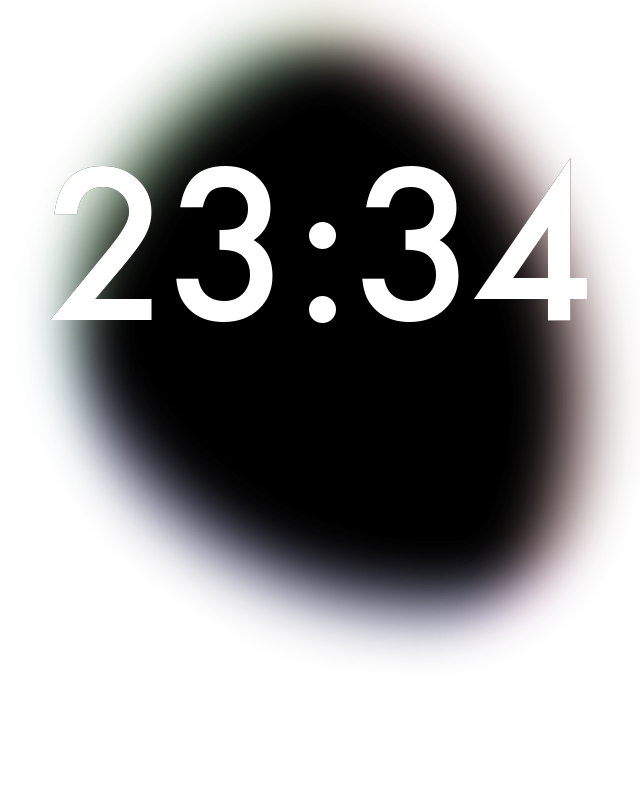

In [80]:
track_id = '0'
res = (640, 800)
t = ""
font_family = "/System/Library/Fonts//Futura.ttc"
font = ImageFont.truetype(font_family, 200)
time_s = datetime.now().strftime("%H:%M")
_, _, tw, th = font.getbbox(time_s)
extended_y = Image.new('RGBA', res, (255,255,255,0))
draw = ImageDraw.Draw(extended_y)
t = time.time()/30/60
draw.circle((320 + 160*math.sin(-t/5), 320+ 160*math.cos(-t/5)), 400, (127, 127, 0, 255))
extended_m = Image.new('RGBA', res, (255,255,255,0))
draw = ImageDraw.Draw(extended_m)
draw.circle((320 + 160*math.sin(t/7), 320+ 160*math.cos(t/7)), 400, (127, 0, 127, 255))
extended_c = Image.new('RGBA', res, (255,255,255,0))
draw = ImageDraw.Draw(extended_c)
draw.circle((320 + 160*math.sin(t/11), 320+ 160*math.cos(t/11)), 400, (0, 127, 127, 255))
extended = Image.new('RGBA', res, (255,255,255,255))
extended = ImageChops.multiply(extended, extended_c.filter(filter=ImageFilter.GaussianBlur(30)))
extended = ImageChops.multiply(extended, extended_m.filter(filter=ImageFilter.GaussianBlur(30)))
extended = ImageChops.multiply(extended, extended_y.filter(filter=ImageFilter.GaussianBlur(30)))
draw = ImageDraw.Draw(extended)
draw.text((320, 320), time_s, (255, 255, 255, 255), font=font, anchor="ms", outline=None)
display(extended)

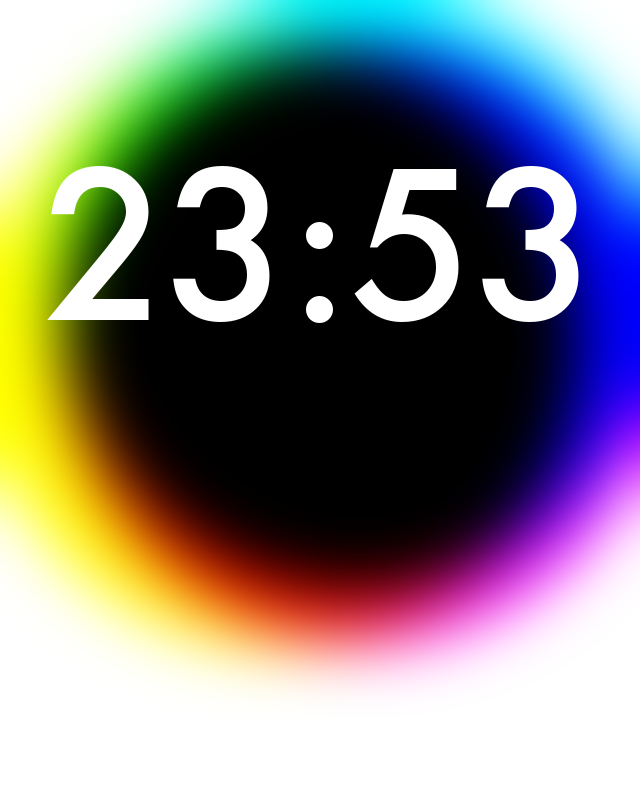

In [106]:
track_id = '0'
res = (640, 800)
t = ""
font_family = "/System/Library/Fonts//Futura.ttc"
font = ImageFont.truetype(font_family, 200)
time_s = datetime.now().strftime("%H:%M")
_, _, tw, th = font.getbbox(time_s)
t = time.time()/30/60
extends = [Image.new('L', res, (0)), Image.new('L', res, (0)), Image.new('L', res, (0))]
draws = [ImageDraw.Draw(ex) for ex in extends]
draws[0].circle((320 + 50*math.sin(-t/5), 320 + 50*math.cos(-t/5)), 300, (255))
draws[1].circle((320 + 50*math.sin(t/7), 320 + 50*math.cos(t/7)), 300, (255))
draws[2].circle((320 + 50*math.sin(t/11), 320 + 50*math.cos(t/11)), 300, (255))
for k in range(3):
    extends[k] = extends[k].filter(filter=ImageFilter.GaussianBlur(30))
extended = ImageChops.invert(Image.merge('RGB', extends))
draw = ImageDraw.Draw(extended)
draw.text((320, 320), time_s, (255, 255, 255, 255), font=font, anchor="ms", outline=None)
display(extended)

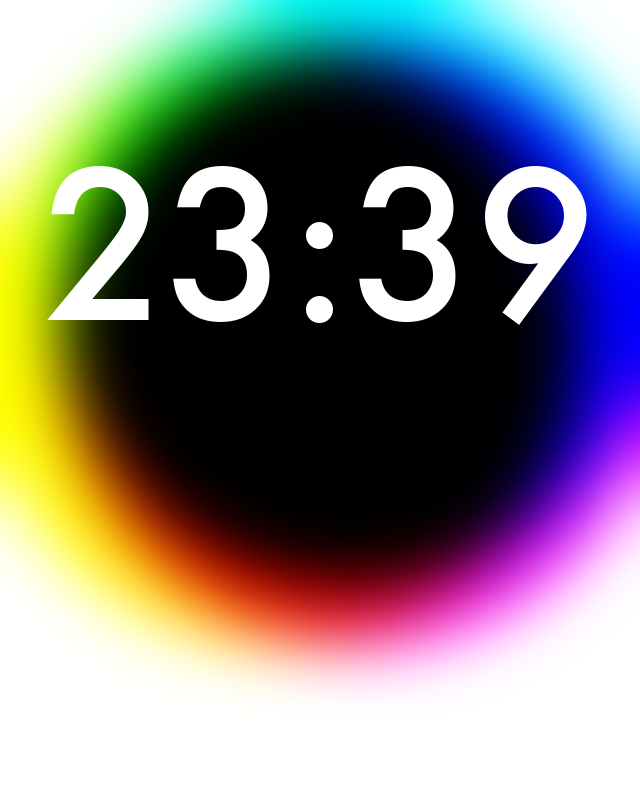

In [86]:
track_id = '0'
res = (640, 800)
t = ""
font_family = "/System/Library/Fonts//Futura.ttc"
font = ImageFont.truetype(font_family, 200)
time_s = datetime.now().strftime("%H:%M")
_, _, tw, th = font.getbbox(time_s)
t = time.time()/30/60
extends = [Image.new('L', res, (0)), Image.new('L', res, (0)), Image.new('L', res, (0))]
draws = [ImageDraw.Draw(ex) for ex in extends]
def Ps(t):
    return ((320 + 50*math.sin(t), 320 + 50*math.cos(t)), (320 + 50*math.sin(t), 320 + 50*math.cos(t)), (320 + 50*math.sin(t), 320 + 50*math.cos(t)))
draws[0].polygon((320 + 50*math.sin(-t/5), 320 + 50*math.cos(-t/5)), 300, (255))
draws[1].polygon((320 + 50*math.sin(t/7), 320 + 50*math.cos(t/7)), 300, (255))
draws[2].polygon((320 + 50*math.sin(t/11), 320 + 50*math.cos(t/11)), 300, (255))
for k in range(3):
    extends[k] = extends[k].filter(filter=ImageFilter.GaussianBlur(30))
extended = ImageChops.invert(Image.merge('RGB', extends))
draw = ImageDraw.Draw(extended)
draw.text((320, 320), time_s, (255, 255, 255, 255), font=font, anchor="ms", outline=None)
display(extended)

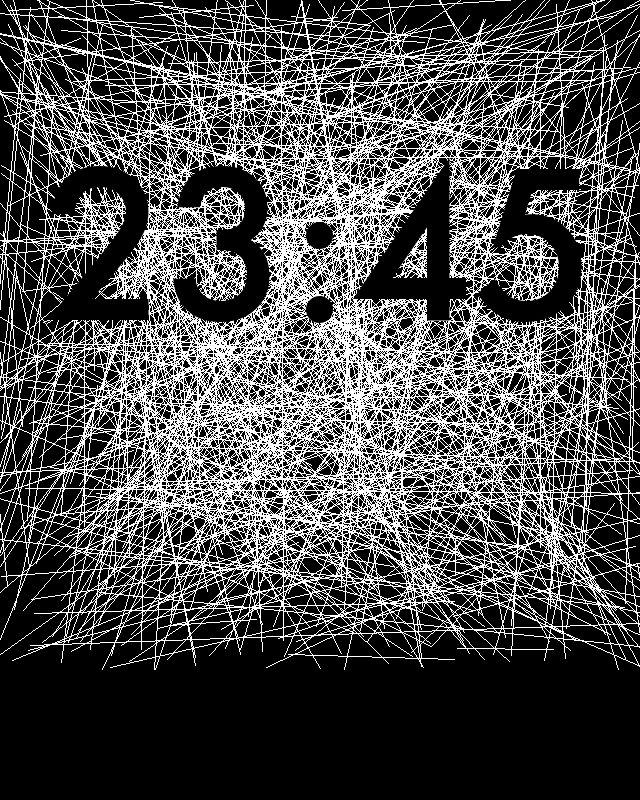

In [105]:
track_id = '0'
res = (640, 800)
t = ""
font_family = "/System/Library/Fonts//Futura.ttc"
clear_output()
font = ImageFont.truetype(font_family, 200)
time_s = datetime.now().strftime("%H:%M")
extended = Image.new('L', res, (0))
draw = ImageDraw.Draw(extended)
for _ in range(700):
   draw.line((random.uniform(-20,670),random.uniform(-20,670),(random.uniform(-20,670),random.uniform(-20,670))), (255), 1)
#draw.line(())
draw.text((320, 320), time_s, (0), font=font, anchor="ms", outline=None)
display(extended)

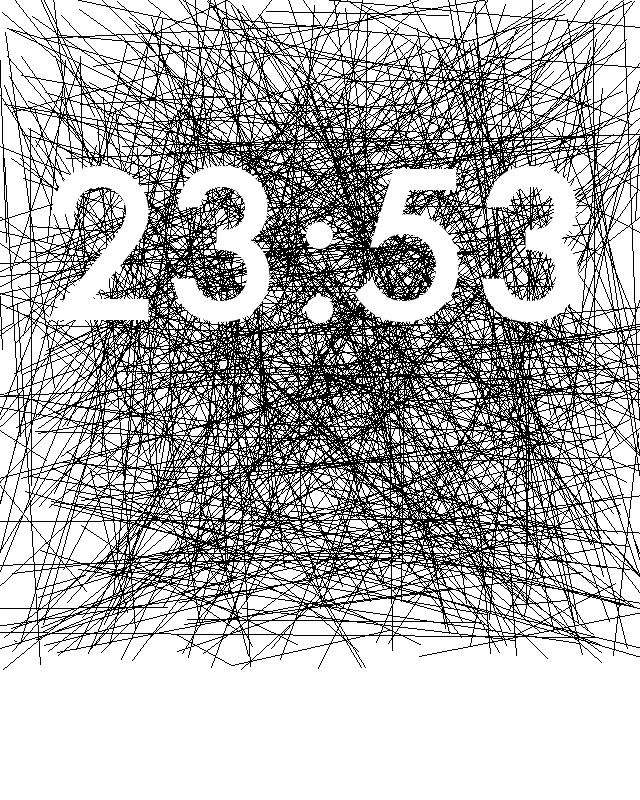

In [107]:
track_id = '0'
res = (640, 800)
t = ""
font_family = "/System/Library/Fonts//Futura.ttc"
clear_output()
font = ImageFont.truetype(font_family, 200)
time_s = datetime.now().strftime("%H:%M")
extended = Image.new('L', res, (255))
draw = ImageDraw.Draw(extended)
for _ in range(700):
   draw.line((random.uniform(-20,670),random.uniform(-20,670),(random.uniform(-20,670),random.uniform(-20,670))), (0), 1)
#draw.line(())
draw.text((320, 320), time_s, (255), font=font, anchor="ms", outline=None)
display(extended)

In [77]:
url = ''
font_family = "/System/Library/Fonts//Futura.ttc"
res = (1200, 1600)
while True:
    new_url = dev.get_cover()
    if new_url is None:
        print('None', end='\r')
    else:
        if new_url != url:
            clear_output()
            img = dev.fetch_img(new_url)
            img = img.resize((res[0],res[0]), Image.Resampling.LANCZOS)
            meta_data = dev.media_info()
            annotation1, annotation2 = f"{meta_data['title']}", f"{meta_data['album']}\t-\t{meta_data['artist']}"
            extended = ImageOps.expand(img, border=(0,0,0,res[1]-res[0]), fill=(0,0,0))
            w, h = extended.size
            font_size_1_found = False
            font_size = 100
            font1 = ImageFont.truetype(font_family, font_size)
            _, _, tw, th = font1.getbbox(annotation1)
            fs_guess = math.floor(8*max(3.0*tw/2.0/w , (h - res[0] )/2.0/th))
            print(fs_guess)
            for k in range(fs_guess, 999999, 10):
                font_size = k
                font1 = ImageFont.truetype(font_family, font_size)
                _, _, tw, th = font1.getbbox(annotation1)
                if 2*th > h - res[0] or 10*tw > 8*w:
                    font_size = k - 1
                    font1 = ImageFont.truetype(font_family, font_size)
                    break
            for k in range(int(font_size/2), 0,-1):
                font_size = k
                font2 = ImageFont.truetype(font_family, font_size)
                _, _, tw, th = font2.getbbox(annotation2)
                if 2*th < h - res[0] and 3*tw < 2*w:
                    font2 = ImageFont.truetype(font_family, font_size)
                    print(font_size, 2)
                    break
            _, _, tw, th = font1.getbbox(annotation1)
            # Get drawing context and annotate
            draw = ImageDraw.Draw(extended)
            draw.text((20, res[0]), annotation1,(255,255,255), font=font1)
            draw.text((20, res[0] + th+10), annotation2,(255,255,255), font=font2)
        display.set_image(img)
        display.show()
    url = new_url
    time.sleep(1)

KeyboardInterrupt: 